In [ ]:
!pip install transformers --quiet
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: RISHIT MAHINDRU
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


100%|██████████| 3.30M/3.30M [00:00<00:00, 228MB/s]

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer,AutoModel
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

cuda


In [ ]:
data_df=pd.read_json("/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json",lines=True)
data_df.dropna(inplace=True)
data_df.drop_duplicates(inplace=True)
data_df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(np.array(data_df["headline"]), np.array(data_df["is_sarcastic"]), test_size=0.3,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)

In [ ]:
print("Training set is: ", X_train.shape[0], " rows which is ", round(X_train.shape[0]/data_df.shape[0],4)*100, "%")
print("Validation set is: ",X_val.shape[0], " rows which is ", round(X_val.shape[0]/data_df.shape[0],4)*100, "%")
print("Testing set is: ",X_test.shape[0], " rows which is ", round(X_test.shape[0]/data_df.shape[0],4)*100, "%")

Training set is:  18695  rows which is  70.0 %
Validation set is:  4006  rows which is  15.0 %
Testing set is:  4007  rows which is  15.0 %


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
class dataset(Dataset):
    def __init__(self, X, Y):
        self.X = [tokenizer(x,
                            max_length = 100,
                            truncation = True,
                            padding = 'max_length',
                            return_tensors='pt').to(device)
                  for x in X
                 ]

        self.Y = torch.tensor(Y, dtype = torch.float32).to(device)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index], self.Y[index]

training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [ ]:
BATCH_SIZE = 32
EPOCHS = 10
LR = 2e-5

In [ ]:
train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle= True)
validation_dataloader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle= False)
testing_dataloader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle= False)

In [ ]:
class MyModel(nn.Module):
    def __init__(self, bert):

        super(MyModel, self).__init__()

        self.bert = bert
        self.dropout = nn.Dropout(0.25)
        self.linear1 = nn.Linear(768, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.linear2 = nn.Linear(256,1)

    def forward(self, input_ids, attention_mask):
        pooled_output = self.bert(input_ids, attention_mask, return_dict = False)[0][:,0]
        output = self.linear1(pooled_output)
        output = self.relu(output)
        output = self.dropout(output)
        output = self.linear2(output)
        return output

In [ ]:
for param in bert_model.parameters():
    param.requires_grad = False
model = MyModel(bert_model).to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr= LR)

In [ ]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):

    model.train()

    total_loss_train = 0
    total_acc_train = 0

    for inputs, labels in train_dataloader:

        input_ids = inputs['input_ids'].squeeze(1).to(device)
        attention_mask = inputs['attention_mask'].squeeze(1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask).squeeze(1)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss_train += loss.item()

        predictions = (torch.sigmoid(outputs) >= 0.5).float()
        total_acc_train += (predictions == labels).sum().item()

    ##############################################
    ## Validation
    ##############################################

    model.eval()

    total_loss_val = 0
    total_acc_val = 0

    with torch.no_grad():

        for inputs, labels in validation_dataloader:

            input_ids = inputs['input_ids'].squeeze(1).to(device)
            attention_mask = inputs['attention_mask'].squeeze(1).to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask).squeeze(1)

            loss = criterion(outputs, labels)

            total_loss_val += loss.item()

            predictions = (torch.sigmoid(outputs) >= 0.5).float()

            total_acc_val += (predictions == labels).sum().item()

    train_loss = total_loss_train / len(train_dataloader)
    val_loss = total_loss_val / len(validation_dataloader)

    train_acc = 100 * total_acc_train / len(training_data)
    val_acc = 100 * total_acc_val / len(validation_data)

    total_loss_train_plot.append(train_loss)
    total_loss_validation_plot.append(val_loss)

    total_acc_train_plot.append(train_acc)
    total_acc_validation_plot.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.2f}%")
    print("-"*60)

Epoch 1
Train Loss: 0.4108 | Train Accuracy: 82.04%
Validation Loss: 0.3848 | Validation Accuracy: 82.98%
------------------------------------------------------------
Epoch 2
Train Loss: 0.4030 | Train Accuracy: 82.39%
Validation Loss: 0.3768 | Validation Accuracy: 83.37%
------------------------------------------------------------
Epoch 3
Train Loss: 0.3951 | Train Accuracy: 82.47%
Validation Loss: 0.3686 | Validation Accuracy: 83.77%
------------------------------------------------------------
Epoch 4
Train Loss: 0.3900 | Train Accuracy: 83.06%
Validation Loss: 0.3619 | Validation Accuracy: 83.65%
------------------------------------------------------------
Epoch 5
Train Loss: 0.3851 | Train Accuracy: 83.05%
Validation Loss: 0.3549 | Validation Accuracy: 84.27%
------------------------------------------------------------
Epoch 6
Train Loss: 0.3790 | Train Accuracy: 83.47%
Validation Loss: 0.3556 | Validation Accuracy: 84.35%
-----------------------------------------------------------

In [ ]:
model.eval()

total_loss_test = 0
total_acc_test = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for inputs, labels in testing_dataloader:

        input_ids = inputs['input_ids'].squeeze(1).to(device)
        attention_mask = inputs['attention_mask'].squeeze(1).to(device)
        labels = labels.to(device)

        outputs = model(input_ids, attention_mask).squeeze(1)

        loss = criterion(outputs, labels)

        total_loss_test += loss.item()

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        total_acc_test += (predictions == labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = total_loss_test / len(testing_dataloader)
test_accuracy = 100 * total_acc_test / len(testing_data)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Loss : 0.3419
Test Accuracy : 84.35%


In [ ]:
print(classification_report(all_labels, all_predictions))

cm = confusion_matrix(all_labels, all_predictions)
print(cm)

              precision    recall  f1-score   support

         0.0       0.85      0.87      0.86      2223
         1.0       0.83      0.82      0.82      1784

    accuracy                           0.84      4007
   macro avg       0.84      0.84      0.84      4007
weighted avg       0.84      0.84      0.84      4007

[[1926  297]
 [ 330 1454]]


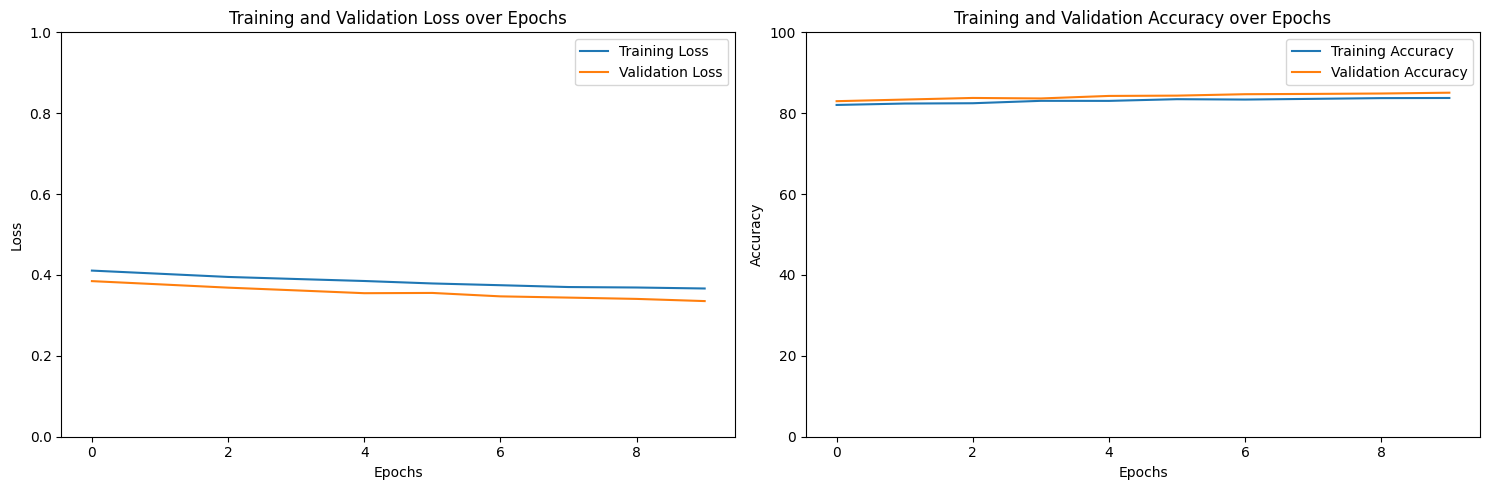

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 1])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()

In [ ]:
torch.save(model.state_dict(), "bert_sarcasm_classifier.pth")


In [ ]:
print(type(tokenizer))

<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>


In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer.save_pretrained("tokenizer")

('tokenizer/tokenizer_config.json', 'tokenizer/tokenizer.json')

In [ ]:
from google.colab import files
import shutil

shutil.make_archive("sarcasm_model", "zip", ".")

files.download("sarcasm_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>